# Week 7 - Milestone 2: MotorPH Analytical Dashboard (Draft)

**Course:** MO-IT106 Data Analytics Fundamentals  
**Datasets:** `MotorPH_Products_Preprocessed.csv` (cleaned in Milestone 1) and `MotorPH_Sales_Preprocessed.csv`  
**Tools:** Python, pandas, matplotlib

**Goal:** Show how MotorPH's products are distributed across product categories, and explain what the distribution means for MotorPH's inventory and purchasing decisions.

**Contents:** 1) Load and validate, 2) Summarize, 3) Chart, 4) Check the output, 5) Extension: compare with sales, 6) Troubleshooting log, 7) Explanation of insights.

## Step 1: Load and validate the cleaned dataset
The data must be accurate, complete and ready for visualization. These reusable functions check the file, the category column, blank values and duplicates before anything is charted.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PRODUCTS_FILE = "MotorPH_Products_Preprocessed.csv"
SALES_FILE = "MotorPH_Sales_Preprocessed.csv"
CATEGORY_COL = "Product Type"


def load_csv(path):
    """Load a CSV file, stopping with a clear message if it is missing or empty."""
    if not Path(path).exists():
        sys.exit(f"ERROR: file not found -> {path} (keep it in the same folder as this script)")
    data = pd.read_csv(path)
    if data.empty:
        sys.exit(f"ERROR: {path} is empty.")
    return data


def validate_categories(data, column):
    """Check the category column exists, drop blank categories and report data quality."""
    if column not in data.columns:
        sys.exit(f"ERROR: column '{column}' not found. Available columns: {list(data.columns)}")
    blank = data[column].isna() | (data[column].astype(str).str.strip() == "")
    clean = data[~blank].copy()
    clean[column] = clean[column].astype(str).str.strip()
    report = {
        "Rows loaded": len(data),
        "Blank categories removed": int(blank.sum()),
        "Duplicate rows": int(clean.duplicated().sum()),
        "Duplicate Product IDs": int(clean["Product ID Number"].duplicated().sum()),
        "Rows used": len(clean),
    }
    return clean, report


products = load_csv(PRODUCTS_FILE)
products, report = validate_categories(products, CATEGORY_COL)

for key, value in report.items():
    print(f"{key}: {value}")
print()
print(products.head().to_string(index=False))

Rows loaded: 50
Blank categories removed: 0
Duplicate rows: 0
Duplicate Product IDs: 0
Rows used: 50

 Product ID Number              Product Name Product Type  Unit Price  Date of Manufacturing  Date of Acquisition
                 1             Honda CBR500R        Sport      389000                   2021                 2023
                 2              Yamaha MT-15   Naked Bike      178000                   2022                 2023
                 3        Kawasaki Ninja 400        Sport      340000                   2023                 2024
                 4     Suzuki Raider R150 Fi    Underbone      119900                   2020                 2021
                 5 Royal Enfield Classic 350      Classic      250000                   2022                 2023


## Step 2: Summarize products per category
Count the products in each category and compute each category's share of the total.

In [3]:
def summarize_categories(data, column):
    """Count products per category and compute each category's share of the total."""
    counts = data[column].value_counts()
    table = pd.DataFrame({
        "Category": counts.index,
        "Product Count": counts.values,
        "Percentage (%)": (counts.values / counts.sum() * 100).round(1),
    })
    # Correctness check: the counts must add up to the number of products
    assert table["Product Count"].sum() == len(data), "Category counts do not match the number of products."
    return table


summary = summarize_categories(products, CATEGORY_COL)
total = int(summary["Product Count"].sum())

print(f"Total products: {total}")
print(f"Number of categories: {len(summary)}\n")
print(summary.to_string(index=False))

Total products: 50
Number of categories: 17

     Category  Product Count  Percentage (%)
      Scooter             12            24.0
   Naked Bike              7            14.0
        Sport              4             8.0
    Adventure              4             8.0
      Cruiser              4             8.0
    Underbone              3             6.0
   Dual-Sport              3             6.0
   Cafe Racer              2             4.0
     Commuter              2             4.0
     Heritage              2             4.0
      Classic              1             2.0
        Retro              1             2.0
Sport Touring              1             2.0
    Scrambler              1             2.0
     Standard              1             2.0
      Touring              1             2.0
       Street              1             2.0


## Step 3: Chart the distribution of products by category

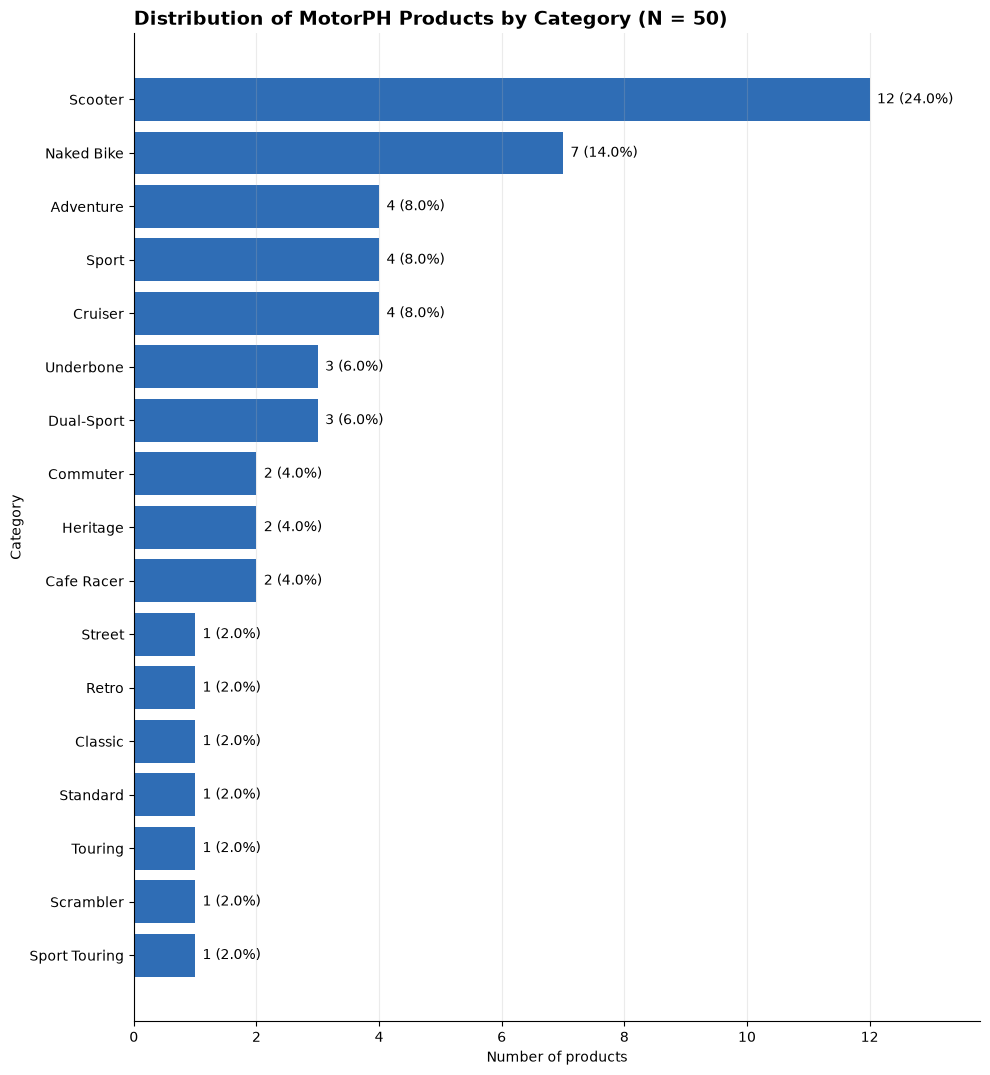

In [4]:
def plot_category_distribution(table, total, out_path):
    """Horizontal bar chart of products per category, sorted largest first and labelled."""
    ordered = table.sort_values("Product Count")  # largest category ends up on top
    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(ordered) + 1.5)))
    bars = ax.barh(ordered["Category"], ordered["Product Count"], color="#2F6DB5")

    for bar, count, pct in zip(bars, ordered["Product Count"], ordered["Percentage (%)"]):
        ax.text(bar.get_width() + ordered["Product Count"].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{count} ({pct}%)", va="center", fontsize=10)

    ax.set_title(f"Distribution of MotorPH Products by Category (N = {total})",
                 fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("Number of products")
    ax.set_ylabel("Category")
    ax.set_xlim(0, ordered["Product Count"].max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    return fig


plot_category_distribution(summary, total, "product_distribution_by_category.png")
summary.to_csv("product_distribution_by_category.csv", index=False)
plt.show()

**Why a horizontal bar chart?** Product type is categorical, and the task is to compare how many products each category holds. Bar length maps directly to the count, which is the most accurate way for the eye to compare categories, and horizontal bars keep 17 long category names readable. The bars are sorted from largest to smallest and labelled with the count and percentage, so the ranking and each category's share of the 50 products can be read without checking the axis. A pie chart was rejected because 17 slices would be hard to compare, and a vertical bar chart would force the labels to overlap or rotate.

## Step 4: Check the output and pull out the key numbers
Every number quoted in the explanation comes from the code, so the table, chart and written explanation stay consistent.

In [5]:
top, second = summary.iloc[0], summary.iloc[1]
singletons = summary[summary["Product Count"] == 1]

print(f"Largest category : {top['Category']} - {top['Product Count']} products ({top['Percentage (%)']}%)")
print(f"2nd largest      : {second['Category']} - {second['Product Count']} products ({second['Percentage (%)']}%)")
print(f"Top 2 share      : {summary['Percentage (%)'].iloc[:2].sum():.0f}%")
print(f"Top 5 share      : {summary['Percentage (%)'].iloc[:5].sum():.0f}%")
print(f"Categories with only 1 product: {len(singletons)} -> {', '.join(singletons['Category'])}")
print(f"Share of catalog in single-product categories: {singletons['Percentage (%)'].sum():.0f}%")

Largest category : Scooter - 12 products (24.0%)
2nd largest      : Naked Bike - 7 products (14.0%)
Top 2 share      : 38%
Top 5 share      : 62%
Categories with only 1 product: 7 -> Classic, Retro, Sport Touring, Scrambler, Standard, Touring, Street
Share of catalog in single-product categories: 14%


## Step 5: Extension - compare the product mix with sales
This second data source tests whether the number of products in a category matches how much that category sells. It adds context for MotorPH's inventory and purchasing decisions.

In [6]:
sales = load_csv(SALES_FILE)

# Validation before using any sales figure
unmatched = set(sales["Product Name"]) - set(products["Product Name"])
print(f"Sales records: {len(sales)} ({sales['Date'].min()} to {sales['Date'].max()})")
print(f"Sales records with a product not in the product list: {len(unmatched)}")
assert not unmatched, f"Unmatched products: {unmatched}"
assert (sales["Quantity"] * sales["Unit Price"] == sales["Total"]).all(), "Total != Quantity x Unit Price"

merged = sales.merge(products[["Product Name", CATEGORY_COL]], on="Product Name", how="left")
assert merged[CATEGORY_COL].notna().all()

by_category = merged.groupby(CATEGORY_COL).agg(Units=("Quantity", "sum"), Sales=("Total", "sum"))
comparison = summary.set_index("Category").join(by_category)
comparison["Unit share (%)"] = (comparison["Units"] / comparison["Units"].sum() * 100).round(1)
comparison["Sales share (%)"] = (comparison["Sales"] / comparison["Sales"].sum() * 100).round(1)
comparison["Sales per product (millions)"] = (comparison["Sales"] / comparison["Product Count"] / 1e6).round(1)
comparison["Gap (sales share - product share)"] = (comparison["Sales share (%)"] - comparison["Percentage (%)"]).round(1)

show = ["Product Count", "Percentage (%)", "Unit share (%)", "Sales share (%)",
        "Sales per product (millions)", "Gap (sales share - product share)"]
print()
print(comparison.sort_values("Sales share (%)", ascending=False)[show].to_string())

Sales records: 994 (2025-01-13 to 2025-08-31)
Sales records with a product not in the product list: 0

               Product Count  Percentage (%)  Unit share (%)  Sales share (%)  Sales per product (millions)  Gap (sales share - product share)
Category                                                                                                                                      
Scooter                   12            24.0            23.0             16.8                          62.3                               -7.2
Cruiser                    4             8.0             8.1             14.2                         158.8                                6.2
Naked Bike                 7            14.0            12.2             12.6                          80.5                               -1.4
Heritage                   2             4.0             4.0             12.4                         276.6                                8.4
Adventure                  4           

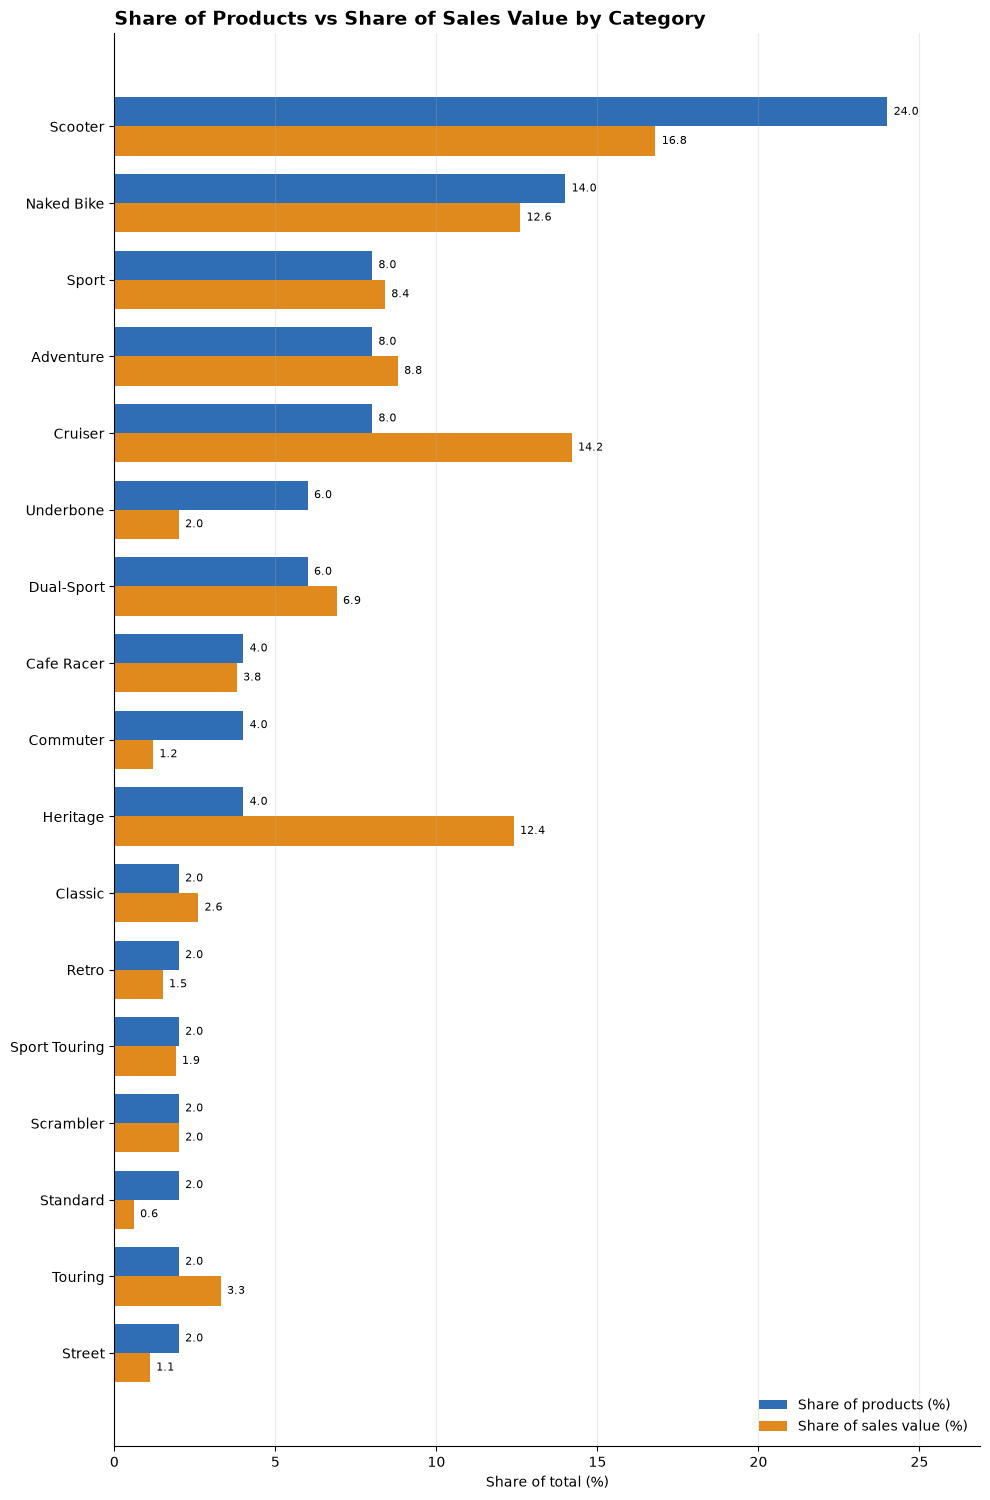

In [7]:
def plot_share_comparison(table, out_path):
    """Grouped horizontal bars: share of products vs share of sales value per category."""
    ordered = table.iloc[::-1]  # keep the same order as the first chart (largest on top)
    height = 0.38
    positions = range(len(ordered))
    fig, ax = plt.subplots(figsize=(10, max(5, 0.8 * len(ordered) + 1.5)))
    ax.barh([p + height / 2 for p in positions], ordered["Percentage (%)"], height,
            color="#2F6DB5", label="Share of products (%)")
    ax.barh([p - height / 2 for p in positions], ordered["Sales share (%)"], height,
            color="#E08A1E", label="Share of sales value (%)")
    for p, a, b in zip(positions, ordered["Percentage (%)"], ordered["Sales share (%)"]):
        ax.text(a + 0.2, p + height / 2, f"{a:.1f}", va="center", fontsize=8)
        ax.text(b + 0.2, p - height / 2, f"{b:.1f}", va="center", fontsize=8)
    ax.set_yticks(list(positions))
    ax.set_yticklabels(ordered.index)
    ax.set_xlabel("Share of total (%)")
    ax.set_title("Share of Products vs Share of Sales Value by Category",
                 fontsize=14, fontweight="bold", loc="left")
    ax.set_xlim(0, max(ordered["Percentage (%)"].max(), ordered["Sales share (%)"].max()) * 1.12)
    ax.legend(loc="lower right", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    return fig


plot_share_comparison(comparison, "products_vs_sales_share.png")
comparison.to_csv("products_vs_sales_by_category.csv")
plt.show()

## Explanation of insights

**Overview.** The cleaned MotorPH dataset from Milestone 1 contains 50 products across 17 product types. The script counts the products in each type and plots the result as a sorted horizontal bar chart, so the categories can be compared at a glance. The aim is to show how the catalog is distributed and what that distribution means for the business.

**What the product distribution shows.** The catalog is concentrated in a few categories. Scooters are the largest category with 12 products (24%), almost double the second-largest, Naked Bikes, with 7 (14%). Together these two types make up 38% of the catalog, and the top five types (adding Adventure, Sport and Cruiser at 4 products each) make up 62%. At the other end, seven types (Street, Retro, Classic, Standard, Touring, Scrambler and Sport Touring) have only one product each, or 14% of the catalog. As a result, each of these niche segments depends on a single model, so one stock-out or discontinued model would remove the whole category from the lineup.

**Connecting the distribution to sales.** To test whether the catalog mix reflects what actually sells, the product list was merged with the sales records (994 transactions from 13 January to 31 August 2025). All sales records matched a product, and every Total equals Quantity multiplied by Unit Price. The comparison shows that the number of models in a category is not the same as its sales. Scooters hold 24.0% of the products but 16.8% of sales value, even though they lead in units sold (23.0% of all units). This is because scooters are lower-priced, so they sell in high volume but earn less per model (about 62.3 million in sales value per scooter model). In contrast, Cruisers are only 8.0% of the products but 14.2% of sales value, and Heritage bikes are just 4.0% of the products (two models) but 12.4% of sales value, the highest sales per model of any category (about 276.6 million). Therefore, a small number of higher-priced models carries a disproportionate share of sales. At the opposite end, Underbone and Commuter together are 10.0% of the products but only 3.2% of sales value.

**Implications and practical applications for MotorPH.** For inventory and purchasing managers, this suggests three actions:
- Keep scooters as the volume anchor, but do not rely on them alone for revenue, because their share of sales value is lower than their share of the catalog.
- Prioritize stock and model variety in Cruiser and Heritage, because they earn the most per model. Heritage is especially exposed since only two models generate 12.4% of sales value.
- Review Underbone and Commuter models, since they take up 10% of the catalog but contribute little sales value, making them candidates for promotion or range reduction.

**Limitations and future applications.** The sales records cover only 13 January to 31 August 2025, and sales value depends on price as well as demand, so these results show a pattern rather than a proven cause. Some category labels also overlap in meaning (for example Sport and Sport Touring, or Classic, Retro and Heritage), which may make the catalog look more fragmented than it is. Next steps are to group similar labels into broader segments, track the comparison month by month, and reuse the same functions for other columns such as price brackets, which also addresses the Milestone 1 mentor feedback about computing tiers in code.

**Correctness check.** The category counts add up to 50, matching the dataset. No blank categories, duplicate rows or duplicate Product IDs were found, and all percentages are computed from the data by the code above, not typed by hand.